In [ ]:
"""
Version 1.1
Date: 4.10.2026
"""

In [2]:
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn
import astropy.units as units
from astropy.table import Table, join

import sys
sys.path.insert(0, '.')
from mw_dynamics import query, selection, kinematics, dynamics

plt.rcParams['figure.dpi'] = 110  # dpi - Dots Per Inch 

# 1. Data Acquisition

## 1.1. Downloading the APOGEE DR17 (SDSS) and Gaia DR3 Data

In [3]:
""" 1.1.a. APOGEE DR17 (SDSS) """  
apogee_dataset = query.fetch_apogee_dataset(dr=17, local_dir='data')

APOGEE DR17 data is already found: data\apogee_astroNN-DR17.fits


In [4]:
""" 1.1.b. GAIA DR3 """  
# Getting ID list from the apogee_dataset table:
gaia_ids_raw = apogee_dataset[selection.COLUMN_MAP["gaia_source_id"]]

# Filtering data from NaN, None or 0:
gaia_ids = [int(i) for i in gaia_ids_raw if i is not None and not numpy.isnan(i) and int(i)>0]

# Querying Gaia DR3 dataset:
gaia_dataset = query.fetch_gaia_dr3_dataset(source_ids=gaia_ids)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Gaia DR3 data is already found: data\gaia_dr3.fits


In [5]:
""" 1.1.c. Combining the APOGEE DR17 and Gaia DR3 data table taking as reference of 'source_id' """
dataset = join(apogee_dataset, gaia_dataset, keys='source_id', join_type='inner')
print(f'There are {len(dataset)} stars in the main combined data table')
dataset

There are 720982 stars in the main combined data table


APOGEE_ID,LOCATION_ID,TELESCOPE,RA_APOGEE,DEC_APOGEE,TEFF,TEFF_ERR,LOGG,LOGG_ERR,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H,FE_H_ERR,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA,DEC,pmra_1,pmra_error_1,ref_epoch,pmdec_1,pmdec_error_1,phot_g_mean_mag_1,bp_rp,g_rp,VHELIO_AVG,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,ra,dec,parallax,parallax_error,pmra_2,pmra_error_2,pmdec_2,pmdec_error_2,radial_velocity,radial_velocity_error,phot_g_mean_mag_2,ruwe
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,km / s,km / s,mag,
bytes18,int32,bytes8,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32
2M03003170+0008161,2093,apo25m,45.132108,0.137814,5780.8574,161.7498,4.100412,0.19276366,-0.3711875,0.038065936,-0.3396748,0.056596436,-0.34056208,0.14742574,-0.20170288,0.07242561,-0.50567,0.4274107,-0.311168,0.0516732,-0.25780863,0.09804092,-0.29315716,0.063271075,-0.24978566,1.3852366,-0.4487291,0.06891378,-0.33393428,0.15429959,-0.32064444,0.074549675,-0.5413349,0.19922921,-0.43484062,0.14278609,-0.44426933,0.141835,-0.50751007,0.15640938,-0.55461407,0.120849475,-0.43001375,0.07844468,-0.70012385,0.4763723,-0.41499853,0.07969294,409.68743896484375,60.474410175818186,30.524086452345742,2.440885066986084,0.36030170977639553,0.18186007116346195,368.71295166015625,54.42612136748066,370.4024994175685,2.5831414557971617,45.132144414036745,0.1378535532444834,4.722163881935847,0.023343084380030632,2016.0,18.657223456570794,0.016468381509184837,12.356247901916504,0.810368537902832,0.49047279357910156,38.26403,6.370143890380859,6.911157608032227,6.589427229446994,2.4611436670328084,2.007263228687403,2851858288640,8.369862900414725,0.001553919203146753,-0.2569848834364346,35.143005276070845,265.7657446547475,-2.4416450221504338,0.0017288495497930633,1.6828653429270997e-05,0.0019645723967377593,0.15433989245595542,0.1390781938636487,0.14437416696880762,0.9112410621565991,0.8453190410501303,0.8908809143057596,

In [6]:
""" 1.1.d. Removing Duplicate APOGEE Entries (same star observed in multiple fields) """
dataset = selection.deduplicate_stars(dataset, id_column="APOGEE_ID", priority_column="TEFF_ERR")

Deduplication by APOGEE_ID: 720982 rows -> 645373 unique stars (75609 duplicate entries removed)


## 1.2. Filtering Data and Detection the Red Giant Stars in the Milky Way Galaxy

In [7]:
""" 1.2.a. Filtering the APOGEE DR17 and Gaia DR3 Dataset according to the RUWE Parameter and Distance Quality """
filtered_table = selection.quality_cuts(dataset, ruwe_max=1.4, max_dist_err=0.20)

""" 1.2.b. Detection the Red Giant Stars in the Milky Way Galaxy """
red_giants = selection.select_red_giants(filtered_table, logg_max=3.5, teff_min=3500, teff_max=5500)

""" 1.2.c. Filling Missing Gaia Radial Velocities with APOGEE VHELIO_AVG (fallback) """
red_giants = selection.fill_missing_radial_velocity(red_giants, 
                                                    gaia_column="radial_velocity", 
                                                    gaia_error_column="radial_velocity_error", 
                                                    apogee_column="VHELIO_AVG", 
                                                    apogee_manual_error=0.5)

n_before = len(red_giants)
red_giants = red_giants[red_giants["radial_velocity_source"] != "MISSING"]
print(f"Dropped {n_before - len(red_giants)} stars lacking any usable radial velocity "
      f"({len(red_giants)} stars remain).")

n_before = len(red_giants)

red_giants = selection.radial_velocity_quality_cut(red_giants, rv_error_max=10.0)

print(f"Dropped {n_before - len(red_giants)} stars with RV error >= 10 km/s "
      f"({len(red_giants)} stars remain).")

red_giants

quality_cuts: 645373 -> 519280 stars (RUWE<1.4, dist_rel_err<0.2)
Radial velocity: 68790/330681 stars lacked a Gaia DR3 RV; 68781 recovered from APOGEE VHELIO_AVG; 9 still missing and will be dropped.
Dropped 9 stars lacking any usable radial velocity (330672 stars remain).
radial_velocity_quality_cut: 330672 -> 328697 stars (RV error < 10.0 km/s)
Dropped 1975 stars with RV error >= 10 km/s (328697 stars remain).


APOGEE_ID,LOCATION_ID,TELESCOPE,RA_APOGEE,DEC_APOGEE,TEFF,TEFF_ERR,LOGG,LOGG_ERR,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H,FE_H_ERR,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA,DEC,pmra_1,pmra_error_1,ref_epoch,pmdec_1,pmdec_error_1,phot_g_mean_mag_1,bp_rp,g_rp,VHELIO_AVG,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,ra,dec,parallax,parallax_error,pmra_2,pmra_error_2,pmdec_2,pmdec_error_2,radial_velocity,radial_velocity_error,phot_g_mean_mag_2,ruwe,radial_velocity_filled,radial_velocity_error_filled,radial_velocity_source
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,km / s,km / s,mag,,km / s,km / s,
bytes18,int32,bytes8,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float64,float64,str17
2M03003264+0020060,2394,apo25m,45.13603,0.335007,5082.678,45.88348,2.929161,0.08946044,-0.23886596,0.026286077,-0.27634853,0.041929316,0.20072912,0.05797296,-0.1291758,0.03496786,-0.1629886,0.07762017,-0.11622734,0.02373126,-0.08638538,0.04619551,-0.121197775,0.02133355,-0.03533382,0.75700915,-0.11921972,0.019385234,-0.11440685,0.0482875,-0.12207767,0.030498197,-0.16501544,0.03620363,-0.16016942,0.04786438,-0.009682881,0.08062476,-0.13464075,0.04279596,-0.13900116,0.043059595,-0.12663645,0.029403245,-0.17696813,0.06914135,-0.13032448,0.028811498,688.5668334960938,68.48153493202041,37.03718679200244,1.4522918462753296,0.1444379397381425,0.07811704219603051,63.94828414916992,6.359987791699222,694.2097548577987,8.873887879218751,45.13603797419482,0.3350430956016859,-0.7112795435300391,0.017718346789479256,2016.0,-1.4120979387124977,0.016528112813830376,10.253987312316895,1.1545343399047852,0.6582441329956055,-0.5815332,1.0081918239593506,0.8676981925964355,0.9499400486514642,0.36767746400627266,0.2176137030606497,15741055975040,8.584920170252683,0.0030439581942992852,-0.4984810388115563,-14.316573618152175,243.79288109653652,4.4221758649356735,0.005929496073636742,4.487194291089586e-05,0.006691

# 2. Kinematic and Spatial Calculations

## 2.1. Coordinate Transformations and 3D Velocity Derivations of Red Giants

In [8]:
""" 2.1.a. Calculation of the Galactocentric 3D Velocities and Coordinates of the Red Giant Stars in Cartesian Coordinate System """
distance = (red_giants[selection.COLUMN_MAP["distance_pc"]]*units.pc).to(units.kpc)

cartesian_velocities = kinematics.observables_to_galactocentric(
    ra = red_giants['RA'] * units.deg,
    dec = red_giants['DEC'] * units.deg,
    distance = distance,
    pmra = red_giants['pmra_1'] * units.mas / units.yr,
    pmdec = red_giants['pmdec_1'] * units.mas / units.yr,
    radial_velocity = red_giants['radial_velocity']
)
cartesian_velocities

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in kpc
    [(-8.58190367, 0.02612917, -0.49853473),
     (-8.4617324 , 0.01964768, -0.35591499),
     (-8.97978993, 0.04974348, -0.92975953), ...,
     (-8.06517422, 0.06437639, -0.02548726),
     (-6.76685464, 1.54838437, -1.09376536),
     (-7.46796747, 0.7507435 , -0.52048514)]
 (v_x, v_y, v_z) in km / s
    [( 16.96287932, 243.65616806,   5.07175758),
     (-73.73466294, 159.14081338, -20.01160206),
     (-33.53082836, 183.25262704,  -5.50191337), ...,
     (  4.56272076, 236.10762692,  15.85321946),
     ( 16.97320794, 186.08875682, -20.84184464),
     ( 19.43644719, 196.91198609,  -5.69378408)]>

In [9]:
""" 2.1.b. Calculation of the Galactocentric 3D Velocities and Coordinates of the Red Giant Stars in Cylindrical Coordinate System """
cylindrical_velocities = kinematics.galactocentric_cylindrical_velocities(cartesian_velocities)
cylindrical_velocities

{'R_kpc': array([8.58194345, 8.46175521, 8.9799277 , ..., 8.06543114, 6.94174444,
        7.50560816], shape=(328697,)),
 'phi_rad': array([3.13854798, 3.13927071, 3.13605322, ..., 3.1336108 , 2.91664629,
        3.04140077], shape=(328697,)),
 'z_kpc': array([-0.49853473, -0.35591499, -0.92975953, ..., -0.02548726,
        -1.09376536, -0.52048514], shape=(328697,)),
 'v_R_kms': array([-16.22094848,  74.10397936,  34.54542483, ...,  -2.67801942,
         24.96226892,   0.3570182 ], shape=(328697,)),
 'v_phi_kms': array([243.70668505, 158.96917703, 183.06407455, ..., 236.13652433,
        185.18639349, 197.86858842], shape=(328697,)),
 'v_z_kms': array([  5.07175758, -20.01160206,  -5.50191337, ...,  15.85321946,
        -20.84184464,  -5.69378408], shape=(328697,))}

In [10]:
""" 2.1.c. Merging the Cartesian and Cylindrical Values of the Red Giant Stars into a Table """
# 1. Merging the data of cartesian and cylindrical in a dictionary
data = {
    #Start ID
    'APOGEE_ID': red_giants['APOGEE_ID'],

    # 2.1.a. Cartesian Coordinates and Velocities (Galactocentric)
    'X_kpc': cartesian_velocities.x.to_value(units.kpc), 
    'Y_kpc': cartesian_velocities.y.to_value(units.kpc),
    'Z_kpc': cartesian_velocities.z.to_value(units.kpc),
    'Vx_kms': cartesian_velocities.v_x.to_value(units.km / units.s),
    'Vy_kms': cartesian_velocities.v_y.to_value(units.km / units.s),
    'Vz_kms': cartesian_velocities.v_z.to_value(units.km / units.s),

    # 2.1.b. Cylindrical Coordinates and Velocities (Galactocentric)
    'R_kpc': cylindrical_velocities["R_kpc"],
    'phi_rad': cylindrical_velocities["phi_rad"],
    'z_kpc': cylindrical_velocities["z_kpc"],
    'vR_kms': cylindrical_velocities[ "v_R_kms"],
    'Vphi_kms': cylindrical_velocities[ "v_phi_kms"],
    'vz_kms':cylindrical_velocities[ "v_z_kms"]
}

# 2. Generating a Pandas DataFrame
red_giant_kinematics = pandas.DataFrame(data)
red_giant_kinematics

,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms
0,b'2M03003264+0020060',-8.581904,0.026129,-0.498535,16.962879,243.656168,5.071758,8.581943,3.138548,-0.498535,-16.220948,243.706685,5.071758
1,b'2M03015585+0043303',-8.461732,0.019648,-0.355915,-73.734663,159.140813,-20.011602,8.461755,3.139271,-0.355915,74.103979,158.969177,-20.011602
2,b'2M03015781+0044290',-8.979790,0.049743,-0.929760,-33.530828,183.252627,-5.501913,8.979928,3.136053,-0.929760,34.545425,183.064075,-5.501913
3,b'2M02584862+0024097',-8.568953,0.029546,-0.488893,-37.332598,211.035460,-8.793247,8.569004,3.138145,-0.488893,38.060031,210.905482,-8.793247
4,b'2M02583846+0031025',-8.165197,0.002985,-0.028410,7.555384,226.361858,43.205288,8.165198,3.141227,-0.028410,-7.472637,226.364605,43.205288
...,...,...,...,...,...,...,...,...,...,...,...,...,...
328692,b'2M20595259-0028121',-5.222694,3.277297,-2.362233,25.998921,220.570681,-82.990832,6.165810,2.581190,-2.362233,95.217224,200.651563,-82.990832
328693,b'2M20595090-0019451',-6.938141,1.344464,-0.951612,10.124837,178.789227,16.470945,7.067205,2.950186,-0.951612,24.072895,177.450263,16.470945
328694,b'2M20591121-0017174',-8.065174,0.064376,-0.025487,4.562721,236.107627,15.853219,8.065431,3.133611,-0.025487,-2.678019,236.136524,15.853219
328695,b'2M20595928-0010220',-6.766855,1.548384,-1.093765,16.973208,186.088757,-20.841845,6.941744,2.916646,-1.093765,24.962269,185.186393,-20.841845


## 2.2. Selecting Red Giant Stars to Analyze

In [11]:
stars_to_analyze_mask = selection.select_outer_disk(
    red_giant_kinematics, 
    red_giant_kinematics["R_kpc"],
    red_giant_kinematics["z_kpc"],
    R_min=9.00,
    R_max=35.0,
    z_max=3.0
)
print(f"There are {stars_to_analyze_mask.sum()} stars to analyze")
red_giants_df = red_giant_kinematics[stars_to_analyze_mask]
red_giants_df

There are 110339 stars to analyze


,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms
10,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926
12,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414
15,b'2M03052995+0110277',-9.241763,0.056197,-1.179489,40.948537,241.115595,17.760757,9.241934,3.135512,-1.179489,-39.481644,241.360131,17.760757
16,b'2M03044595+0111254',-9.125663,0.053937,-1.059811,58.218803,82.174026,-100.136504,9.125822,3.135682,-1.059811,-57.732110,82.516683,-100.136504
18,b'2M03040493+0116266',-9.549979,0.083313,-1.520525,28.412219,181.423338,32.432617,9.550343,3.132869,-1.520525,-26.828481,181.664290,32.432617
...,...,...,...,...,...,...,...,...,...,...,...,...,...
318346,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339
318388,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN
318404,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739
318416,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382


## 2.3. Spatial Distribution of the Red Giant in the Milky Way

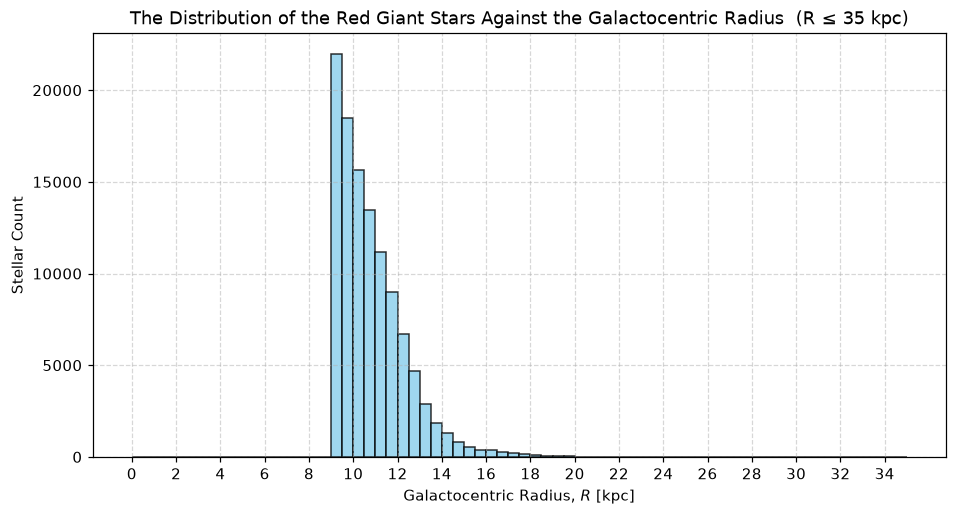

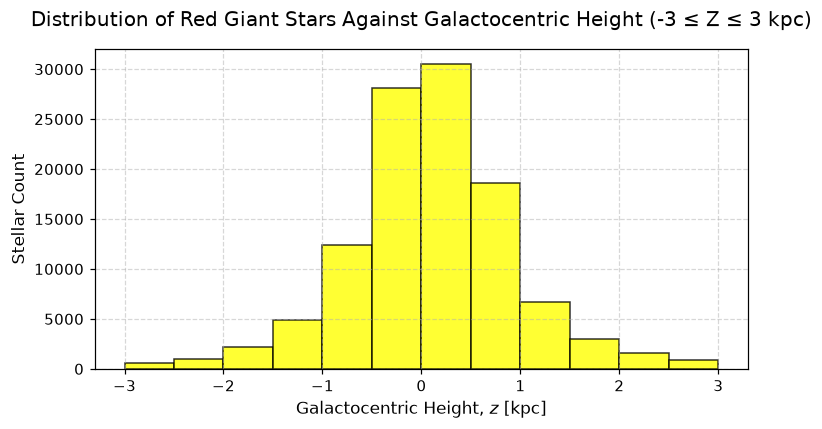

In [12]:
""" 2.3.a. The Distribution of the Red Giant Stars Against the Galactocentric Radius """

plt.figure(figsize=(10, 5))

# The range 0 to 35 are divided into 70 small boxes (each 0.5 kpc wide).
plt.hist(
    red_giants_df["R_kpc"],
    bins=70,
    range=(0, 35),
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

# The X-axis values range from 0 to 35, plotted at intervals of 2.
plt.xticks(numpy.arange(0, 36, 2))

plt.title("The Distribution of the Red Giant Stars Against the Galactocentric Radius  (R ≤ 35 kpc)")
plt.xlabel("Galactocentric Radius, $R$ [kpc]")
plt.ylabel("Stellar Count")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


""" 2.3.b. The Distribution of the Red Giant Stars Against the Galactocentric Z Values """
plt.figure(figsize=(7, 4))

plt.hist(
    red_giants_df["z_kpc"],
    bins=12,
    range=(-3, 3), 
    color="yellow",
    edgecolor="black",
    alpha=0.8,
)

plt.title("Distribution of Red Giant Stars Against Galactocentric Height (-3 ≤ Z ≤ 3 kpc)", fontsize=13, pad=15)
plt.xlabel("Galactocentric Height, $z$ [kpc]", fontsize=11)
plt.ylabel("Stellar Count", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout() 

plt.show()

# 3. Galactic Dynamics and Kinematic Moment Calculations

## 3.1. Radial Binning and RGB Tracer Density
---
In this section, the RGB tracer sample is divided into 1-kpc-wide Galactocentric radial bins (R) between 9 and 35 kpc, and a minimum star count threshold (N ≥ 20) is applied to filter out bins with insufficient data to ensure statistical reliability. 

The number of stars decreases rapidly with increasing radius, from 44,670 stars in the 9–10 kpc bin to fewer than 20 stars beyond 22 kpc. For the initial Jeans analysis, only bins containing at least 20 stars are retained. This provides a preliminary usable radial range of approximately 9.5–21.5 kpc.

In [13]:
""" 3.1.a. Bin Edge and Center Calculation """

# Radial range used for the Jeans analysis
R_MIN = 9.00
R_MAX = 35.0
BIN_WIDTH = 1.00

# Construct radial bin edges
radial_bin_edges = numpy.arange(R_MIN, R_MAX+1, BIN_WIDTH)
print('Radial bin edges: ', radial_bin_edges)

# Calculate bin centres
radial_bin_centers = 0.5 * (radial_bin_edges[:-1] + radial_bin_edges[1:])
print("\nRadial bin centers: ", radial_bin_centers)

Radial bin edges:  [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26.
 27. 28. 29. 30. 31. 32. 33. 34. 35.]

Radial bin centers:  [ 9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5
 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5 33.5 34.5]


In [14]:
""" 3.1.b. Applying Radial Bin Edges to Data """

# Binning red giant stars
assigned_radial_bins = red_giants_df.copy()
assigned_radial_bins["R_bin"] = pandas.cut(
    red_giants_df["R_kpc"],
    bins=radial_bin_edges,
    labels=radial_bin_centers,
    right=False,
    include_lowest=True
)
display(assigned_radial_bins)

# General analysis for binned red giants
radial_bin_counts = (
    assigned_radial_bins.groupby("R_bin", observed=False).size().reset_index(name="N_stars")
)
print(radial_bin_counts)

,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms,R_bin
10,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926,10.5
12,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414,10.5
15,b'2M03052995+0110277',-9.241763,0.056197,-1.179489,40.948537,241.115595,17.760757,9.241934,3.135512,-1.179489,-39.481644,241.360131,17.760757,9.5
16,b'2M03044595+0111254',-9.125663,0.053937,-1.059811,58.218803,82.174026,-100.136504,9.125822,3.135682,-1.059811,-57.732110,82.516683,-100.136504,9.5
18,b'2M03040493+0116266',-9.549979,0.083313,-1.520525,28.412219,181.423338,32.432617,9.550343,3.132869,-1.520525,-26.828481,181.664290,32.432617,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318346,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339,9.5
318388,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN,9.5
318404,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739,10.5
318416,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382,10.5


   R_bin  N_stars
0    9.5    40478
1   10.5    29103
2   11.5    20152
3   12.5    11411
4   13.5     4778
5   14.5     2115
6   15.5      927
7   16.5      612
8   17.5      386
9   18.5      185
10  19.5      107
11  20.5       36
12  21.5       22
13  22.5        9
14  23.5        2
15  24.5        5
16  25.5        4
17  26.5        1
18  27.5        2
19  28.5        1
20  29.5        0
21  30.5        0
22  31.5        0
23  32.5        1
24  33.5        1
25  34.5        1


In [15]:
""" 3.1.c. Selecting Usable Bin Groups """ 

# Selecting bins including more 20 stars
usable_radial_bins = radial_bin_counts[:13]
usable_radial_bins

,R_bin,N_stars
0,9.5,40478
1,10.5,29103
2,11.5,20152
3,12.5,11411
4,13.5,4778
5,14.5,2115
6,15.5,927
7,16.5,612
8,17.5,386
9,18.5,185


In [16]:
""" 3.1.d. Selecting Stars in Usable Radial Bins """

# Selecting stars being 9 ≤ R ≤ 22 kpc (from R_bin 9.5 to 21.5)
velocity_sample = assigned_radial_bins[assigned_radial_bins["R_bin"].isin(usable_radial_bins["R_bin"])].copy()
print(f"Number of stars used for velocity-moment analysis: {len(velocity_sample)}")
velocity_sample

Number of stars used for velocity-moment analysis: 110312


,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms,R_bin
10,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926,10.5
12,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414,10.5
15,b'2M03052995+0110277',-9.241763,0.056197,-1.179489,40.948537,241.115595,17.760757,9.241934,3.135512,-1.179489,-39.481644,241.360131,17.760757,9.5
16,b'2M03044595+0111254',-9.125663,0.053937,-1.059811,58.218803,82.174026,-100.136504,9.125822,3.135682,-1.059811,-57.732110,82.516683,-100.136504,9.5
18,b'2M03040493+0116266',-9.549979,0.083313,-1.520525,28.412219,181.423338,32.432617,9.550343,3.132869,-1.520525,-26.828481,181.664290,32.432617,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318346,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339,9.5
318388,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN,9.5
318404,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739,10.5
318416,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382,10.5


In [17]:
""" 3.1.e. Grouping Stars by Galactocentric Radius """

radial_groups = velocity_sample.groupby("R_bin", observed=True)

## 3.2. First-Order Kinematic Moments: Mean Velocities and Velocity Dispersions
---
One of the foundational components of the Jeans equation, namely **mean velocity components** 
$$\langle V_R\rangle, \langle V_\phi\rangle, \langle V_z\rangle $$
and the corresponding **velocity dispersions**
$$ \sigma_R, \sigma_\phi, \sigma_z $$
are calculated in the **Galactocentric** cylindrical coordinate system for each radial bin.

In [18]:
""" 3.2.a. Mean Velocities and Velocity Dispersions """

# Population standard deviation
def population_std(values):
    return numpy.std(values, ddof=0)

# Calculation of the mean velocities and standard deviations 
velocity_moments = radial_groups.agg(
    # Number of stars
    N_stars = ("vR_kms", "count"),

    # Mean velocities
    mean_vR_kms = ("vR_kms", "mean"),
    mean_Vphi_kms = ("Vphi_kms", "mean"),
    mean_vz_kms = ("vz_kms", "mean"),

    # Velocity dispersions
    sigma_R_kms = ("vR_kms", population_std),
    sigma_phi_kms = ("Vphi_kms", population_std),
    sigma_z_kms = ("vz_kms", population_std)
).reset_index()

velocity_moments

,R_bin,N_stars,mean_vR_kms,mean_Vphi_kms,mean_vz_kms,sigma_R_kms,sigma_phi_kms,sigma_z_kms
0,9.5,36290,-4.747500,211.111071,1.199800,42.800113,38.158525,23.499061
1,10.5,25650,-2.155983,211.414595,1.997510,38.083622,33.404266,20.920025
2,11.5,16941,-0.140120,211.648264,3.074932,34.684877,32.008356,19.718393
3,12.5,8699,1.520944,210.769240,3.980587,32.003754,31.846215,18.786646
4,13.5,3201,-0.458967,205.783620,2.715331,32.765504,31.799035,20.980711
5,14.5,1403,-4.350122,201.597893,0.458137,34.056576,33.284936,21.645505
6,15.5,618,-10.825312,199.485377,-4.902025,34.196108,36.157362,24.138427
7,16.5,436,-11.624950,192.755816,-3.291493,37.334839,44.612268,24.815908
8,17.5,257,-15.514100,193.260244,-3.030008,30.038879,31.998961,22.318851
9,18.5,108,-14.029015,190.784868,-2.186279,22.875824,34.167387,20.987161


## 3.3. Second-Order Kinematic Moments
---
This subsection derives the total mean-square velocity components, namely $$\langle V_R^2\rangle, \langle V_\phi^2\rangle, \langle V_z^2\rangle$$ mathematically combining the previously computed mean velocities and velocity dispersions, which enter directly into the Jeans equation.


In [19]:
""" 3.3.a. Calculation of the Second Velocity Moments """

# Calculation of the Second Velocity Moments
velocity_moments["mean_vR2_kms2"] = (velocity_moments["mean_vR_kms"]**2 + velocity_moments["sigma_R_kms"]**2)
velocity_moments["mean_Vphi2_kms2"] = (velocity_moments["mean_Vphi_kms"]**2 + velocity_moments["sigma_phi_kms"]**2)
velocity_moments["mean_vz2_kms2"] = (velocity_moments["mean_vz_kms"]**2 + velocity_moments["sigma_z_kms"]**2)
velocity_moments

,R_bin,N_stars,mean_vR_kms,mean_Vphi_kms,mean_vz_kms,sigma_R_kms,sigma_phi_kms,sigma_z_kms,mean_vR2_kms2,mean_Vphi2_kms2,mean_vz2_kms2
0,9.5,36290,-4.747500,211.111071,1.199800,42.800113,38.158525,23.499061,1854.388442,46023.957197,553.645388
1,10.5,25650,-2.155983,211.414595,1.997510,38.083622,33.404266,20.920025,1455.010517,45811.976095,441.637482
2,11.5,16941,-0.140120,211.648264,3.074932,34.684877,32.008356,19.718393,1203.060343,45819.522545,398.270223
3,12.5,8699,1.520944,210.769240,3.980587,32.003754,31.846215,18.786646,1026.553516,45437.853965,368.783142
4,13.5,3201,-0.458967,205.783620,2.715331,32.765504,31.799035,20.980711,1073.788909,43358.076882,447.563268
5,14.5,1403,-4.350122,201.597893,0.458137,34.056576,33.284936,21.645505,1178.773935,41749.597619,468.737783
6,15.5,618,-10.825312,199.485377,-4.902025,34.196108,36.157362,24.138427,1286.561181,41101.770344,606.693495
7,16.5,436,-11.624950,192.755816,-3.291493,37.334839,44.612268,24.815908,1529.029642,39145.058970,626.663232
8,17.5,257,-15.514100,193.260244,-3.030008,30.038879,31.998961,22.318851,1143.021551,38373.455544,507.312035
9,18.5,108,-14.029015,190.784868,-2.186279,22.875824,34.167387,20.987161,720.116585,37566.276147,445.240727


## 3.4. Cross-Term Moments
---
The **cross term**,
$$ \langle V_R V_z \rangle $$
describe the relationship between the **radial** and **vertical** motions of stars.

If radial and vertical motions are independent, this term is small. A non-zero value indicates that these two velocity components are correlated.

In [20]:
""" 3.4.a. Calculation of Cross Term """

# Calculating the cross term (V_R * V_z) for each individual star
velocity_sample["cross_term_kms2"] = (velocity_sample["vR_kms"] * velocity_sample["vz_kms"])

# Calculating <V_R V_z> in each radial bin
cross_moments = (
    velocity_sample.groupby("R_bin", observed=True).agg(mean_cross_term_kms2=("cross_term_kms2", "mean")).reset_index()
)

# Adding the cross-term values to the velocitty-moments table
velocity_moments = velocity_moments.merge(cross_moments, on="R_bin", how="left")

# Printing the table
print(velocity_moments)

   R_bin  N_stars  mean_vR_kms  mean_Vphi_kms  mean_vz_kms  sigma_R_kms  \
0    9.5    36290    -4.747500     211.111071     1.199800    42.800113   
1   10.5    25650    -2.155983     211.414595     1.997510    38.083622   
2   11.5    16941    -0.140120     211.648264     3.074932    34.684877   
3   12.5     8699     1.520944     210.769240     3.980587    32.003754   
4   13.5     3201    -0.458967     205.783620     2.715331    32.765504   
5   14.5     1403    -4.350122     201.597893     0.458137    34.056576   
6   15.5      618   -10.825312     199.485377    -4.902025    34.196108   
7   16.5      436   -11.624950     192.755816    -3.291493    37.334839   
8   17.5      257   -15.514100     193.260244    -3.030008    30.038879   
9   18.5      108   -14.029015     190.784868    -2.186279    22.875824   
10  19.5       60     0.197582     165.109886    -8.347108    48.244852   
11  20.5       16     5.500845     105.144235     2.703647    87.828301   
12  21.5        4   -24.6

## 3.5. Radial Gradient of the Radial Velocity Moment
---
A critical numerical input for solving the Jeans equation in Chapter 4, this subsection covers the computation of the radial gradient of the mean-square radial velocity component using numerical differentiation methods.
$$\frac{\partial \langle V_R^2 \rangle}{\partial R}$$


In [21]:
""" 3.5.a. Radial Gradient of the Radial Velocity Second Moment """

# Keep only radial bins with a sufficient number of stars
gradient_sample = velocity_moments.loc[velocity_moments["N_stars"] > 20, ["R_bin", "N_stars", "mean_vR2_kms2"]
].copy()

# Gradient calculation
R = gradient_sample["R_bin"].to_numpy(dtype=float)
vR2 = gradient_sample["mean_vR2_kms2"].to_numpy(dtype=float)
weights = numpy.sqrt(gradient_sample["N_stars"].to_numpy(dtype=float))

vR2_smooth, dvR2_dR = dynamics.fit_polynomial_derivative(R, vR2, weights, degree=2)

# Adding the results to the table
gradient_sample["mean_vR2_kms2_smooth"] = vR2_smooth
gradient_sample["d_mean_vR2_dR"] = dvR2_dR

gradient_sample["fit_residual_kms2"] = gradient_sample["mean_vR2_kms2"] - gradient_sample["mean_vR2_kms2_smooth"]
print("\n", gradient_sample)

---Fitting Polynomial---
        2
45.12 x - 1253 x + 9667

---Analytics Derivative---  
90.24 x - 1253

    R_bin  N_stars  mean_vR2_kms2  mean_vR2_kms2_smooth  d_mean_vR2_dR  \
0    9.5    36290    1854.388442           1834.456616    -395.782044   
1   10.5    25650    1455.010517           1483.796820    -305.537547   
2   11.5    16941    1203.060343           1223.381521    -215.293051   
3   12.5     8699    1026.553516           1053.210718    -125.048555   
4   13.5     3201    1073.788909            973.284412     -34.804058   
5   14.5     1403    1178.773935            983.602601      55.440438   
6   15.5      618    1286.561181           1084.165287     145.684934   
7   16.5      436    1529.029642           1274.972470     235.929431   
8   17.5      257    1143.021551           1556.024149     326.173927   
9   18.5      108     720.116585           1927.320324     416.418423   
10  19.5       60    2327.604825           2388.860995     506.662920   

    fit_residual_

## 3.6. Vertical Gradient of the Cross Term
---
In this section, the **vertical gradient of the cross term**,
$$\frac{\partial \langle V_R V_z \rangle}{\partial z}$$
is calculated to account for the final term in the Jeans equation (See Chapter 4). The vertical height is restricted to **-3 < z < 3 kpc** and divided into **1 kpc bins**.

The numerical gradient is calculated using the mean cross-term $ \langle V_R V_z \rangle $ values previously derived in Section 3.4. Cross-Term Moments. **6 different gradient cross-term values** are obtained as a result of the calculation. 

To accurately capture the dynamics close to the Galactic disk, only the gradient results within the mid-plane region—specifically between **-0.5 and 0.5 kpc**—are extracted and utilized in the subsequent Jeans equation calculations.

In [22]:
""" 3.6.a. Binning Process of the z Values """

# Filtering the z values (-3 < z < 3)
cross_term_sample = velocity_sample[velocity_sample["z_kpc"].abs() < 3.0].copy()

# The edges of the bins
z_bin_width = 1.00 #kpc
z_edges = numpy.arange(-3.00, 3.00+z_bin_width, z_bin_width)
print(z_edges)

# Assigning stars to z bins
cross_term_sample["z_bin"] = pandas.cut(cross_term_sample["z_kpc"], bins=z_edges, include_lowest=True)

# Calculating the centre of each z bin
cross_term_sample["z_bin_center"] = cross_term_sample["z_bin"].apply(lambda interval: interval.mid)

cross_term_sample[["R_bin", "z_kpc", "z_bin_center"]]

[-3. -2. -1.  0.  1.  2.  3.]


,R_bin,z_kpc,z_bin_center
10,10.5,-2.204027,-2.5005
12,10.5,-2.179772,-2.5005
15,9.5,-1.179489,-1.5000
16,9.5,-1.059811,-1.5000
18,9.5,-1.520525,-1.5000
...,...,...,...
318346,9.5,2.009886,2.5000
318388,9.5,2.049427,2.5000
318404,10.5,2.559047,2.5000
318416,10.5,2.426772,2.5000


In [23]:
""" 3.6.b. Classifying Cross-Term Moments in R-z plane """

# Classifying the RGB based on the values of R and z
cross_term_Rz = cross_term_sample.groupby(["R_bin","z_bin","z_bin_center"], observed=True).agg(
    N_stars=("cross_term_kms2", "count"),
    mean_cross_term_kms2=("cross_term_kms2", "mean")
).reset_index()

print(cross_term_Rz)

   R_bin           z_bin z_bin_center  N_stars  mean_cross_term_kms2
0    9.5  (-3.001, -2.0]      -2.5005      475          -1331.805839
1    9.5    (-2.0, -1.0]      -1.5000     1395           -336.352335
2    9.5     (-1.0, 0.0]      -0.5000    13526            -42.512186
3    9.5      (0.0, 1.0]       0.5000    17248             72.430891
4    9.5      (1.0, 2.0]       1.5000     2974            358.244236
..   ...             ...          ...      ...                   ...
73  21.5    (-2.0, -1.0]      -1.5000        2           -118.970288
74  21.5     (-1.0, 0.0]      -0.5000        0                   NaN
75  21.5      (0.0, 1.0]       0.5000        0                   NaN
76  21.5      (1.0, 2.0]       1.5000        1           -299.640586
77  21.5      (2.0, 3.0]       2.5000        0                   NaN

[78 rows x 5 columns]


In [24]:
""" 3.6.c. Vertical Gradient of the Cross Term """

vertical_gradient_results = []

for R_bin, group in cross_term_Rz.groupby("R_bin", observed=True):

    # Sort according to vertical position
    group = group.sort_values("z_bin_center")
    z = group["z_bin_center"].to_numpy(dtype=float)

    cross_term = group["mean_cross_term_kms2"].to_numpy(dtype=float)

    n_per_zbin = group["N_stars"].to_numpy(dtype=float)
    weights = numpy.sqrt(n_per_zbin)

    _, slope_at_zero = dynamics.fit_polynomial_derivative(
        z, cross_term, weights, degree=1, eval_at=numpy.array([0.0])
    )

    
    vertical_gradient_results.append({
        "R_bin": float(R_bin),
        "vertical_gradient_crossTerm": slope_at_zero[0],
        "N_stars_total": int(numpy.nansum(n_per_zbin)),
    })

cross_gradient = pandas.DataFrame(vertical_gradient_results)
cross_gradient

---Fitting Polynomial---
  
251 x + 0.3969

---Analytics Derivative---  
251
---Fitting Polynomial---
  
147.1 x + 9.484

---Analytics Derivative---  
147.1
---Fitting Polynomial---
  
139.2 x - 0.7001

---Analytics Derivative---  
139.2
---Fitting Polynomial---
  
114.8 x + 23.13

---Analytics Derivative---  
114.8
---Fitting Polynomial---
  
111.2 x - 9.221

---Analytics Derivative---  
111.2
---Fitting Polynomial---
  
72.36 x - 1.336

---Analytics Derivative---  
72.36
---Fitting Polynomial---
  
62.54 x + 18.31

---Analytics Derivative---  
62.54
---Fitting Polynomial---
  
-35.24 x - 184.7

---Analytics Derivative---  
-35.24
---Fitting Polynomial---
  
17.52 x - 30.15

---Analytics Derivative---  
17.52
---Fitting Polynomial---
  
-95.3 x + 184.7

---Analytics Derivative---  
-95.3
---Fitting Polynomial---
  
204.6 x - 177.2

---Analytics Derivative---  
204.6
---Fitting Polynomial---
  
8.491 x - 193.6

---Analytics Derivative---  
8.491
---Fitting Polynomial---
  
97.01 x - 28

,R_bin,vertical_gradient_crossTerm,N_stars_total
0,9.5,251.014558,36290
1,10.5,147.123431,25650
2,11.5,139.150077,16941
3,12.5,114.795288,8699
4,13.5,111.249350,3201
5,14.5,72.363204,1403
6,15.5,62.537038,618
7,16.5,-35.238924,436
8,17.5,17.515524,257
9,18.5,-95.297804,108


## 3.7. Jeans Equation Terms Table

In [25]:
table_one = pandas.merge(
    velocity_moments[["R_bin", "mean_vR2_kms2", "mean_Vphi2_kms2", "mean_vz2_kms2"]],
    gradient_sample[["R_bin", "d_mean_vR2_dR"]],
    on="R_bin",
    how="inner"
)

jeans_terms_table = pandas.merge(
    table_one,
    cross_gradient[["R_bin", "vertical_gradient_crossTerm"]],
    on="R_bin",
    how="inner"
)
jeans_terms_table


,R_bin,mean_vR2_kms2,mean_Vphi2_kms2,mean_vz2_kms2,d_mean_vR2_dR,vertical_gradient_crossTerm
0,9.5,1854.388442,46023.957197,553.645388,-395.782044,251.014558
1,10.5,1455.010517,45811.976095,441.637482,-305.537547,147.123431
2,11.5,1203.060343,45819.522545,398.270223,-215.293051,139.150077
3,12.5,1026.553516,45437.853965,368.783142,-125.048555,114.795288
4,13.5,1073.788909,43358.076882,447.563268,-34.804058,111.249350
5,14.5,1178.773935,41749.597619,468.737783,55.440438,72.363204
6,15.5,1286.561181,41101.770344,606.693495,145.684934,62.537038
7,16.5,1529.029642,39145.058970,626.663232,235.929431,-35.238924
8,17.5,1143.021551,38373.455544,507.312035,326.173927,17.515524
9,18.5,720.116585,37566.276147,445.240727,416.418423,-95.297804


# 4. Circular Velocity from the Jeans Equation

In [26]:
# Radial scale length adopted from Jiao et al. (2023)
h_R = 2.5 # kpc

# Converting the R_bin expressions to numerical float values
R = jeans_terms_table["R_bin"].astype(float)

# 1st term of equation
term_1 = jeans_terms_table["mean_Vphi2_kms2"]

# 2nd term of equation
term_2 = ((R - h_R)/h_R) * jeans_terms_table["mean_vR2_kms2"]

# 3rd term of equation
term_3 = -R * jeans_terms_table["d_mean_vR2_dR"]

# 4th term of Jeans equation
term_4 = -R * jeans_terms_table["vertical_gradient_crossTerm"]

# Calculating circular velocity from Jeans equation (cross-term temporarily neglected)
V_circ_squared_kms2 = term_1 + term_2 + term_3 + term_4
"""V_circ_kms = numpy.sqrt(numpy.maximum(V_circ_squared_kms2, 0))"""
V_circ_kms = numpy.where(
    V_circ_squared_kms2 >= 0,
    numpy.sqrt(numpy.maximum(V_circ_squared_kms2, 0)),
    numpy.nan
)

# Generating a table
jeans_term_value = {
    "R_bin":jeans_terms_table["R_bin"],
    "N_stars":gradient_sample["N_stars"],
    "1st term":term_1,
    "2nd term":term_2,
    "3rd term":term_3,
    "4th term":term_4,
    "V_circ_squared_kms2":V_circ_squared_kms2,
    "V_circ_kms":V_circ_kms
}
jeans_terms_value_table = pandas.DataFrame(jeans_term_value)
jeans_terms_value_table

,R_bin,N_stars,1st term,2nd term,3rd term,4th term,V_circ_squared_kms2,V_circ_kms
0,9.5,36290,46023.957197,5192.287637,3759.929417,-2384.638296,52591.535955,229.328446
1,10.5,25650,45811.976095,4656.033653,3208.144249,-1544.796030,52131.357966,228.322925
2,11.5,16941,45819.522545,4331.017234,2475.870088,-1600.225880,51026.183988,225.889761
3,12.5,8699,45437.853965,4106.214063,1563.106935,-1434.941104,49672.233859,222.872685
4,13.5,3201,43358.076882,4724.671198,469.854789,-1501.866227,47050.736642,216.911818
5,14.5,1403,41749.597619,5658.114888,-803.886350,-1049.266464,45554.559694,213.435142
6,15.5,618,41101.770344,6690.118139,-2258.116481,-969.324082,44564.447920,211.102932
7,16.5,436,39145.058970,8562.565994,-3892.835605,581.442251,44396.231611,210.704133
8,17.5,257,38373.455544,6858.129308,-5708.043722,-306.521671,39217.019460,198.032875
9,18.5,108,37566.276147,4608.746142,-7703.740831,1763.009372,36234.290830,190.353069


In [28]:
print(jeans_terms_value_table[["R_bin","V_circ_kms"]])

    R_bin  V_circ_kms
0     9.5  229.328446
1    10.5  228.322925
2    11.5  225.889761
3    12.5  222.872685
4    13.5  216.911818
5    14.5  213.435142
6    15.5  211.102932
7    16.5  210.704133
8    17.5  198.032875
9    18.5  190.353069
10   19.5  178.832916


# 5. Comparison with Literature Rotation Curves

In [31]:
Jiao_rotation_curve_results = {
    'R_bin':[9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5],
    'V_circ_kms':[221.75, 223.32, 220.72, 222.92, 224.16, 221.60, 218.79, 216.38, 212.48, 209.17,206.25]
}
Jiao_dataFrame = pandas.DataFrame(Jiao_rotation_curve_results)

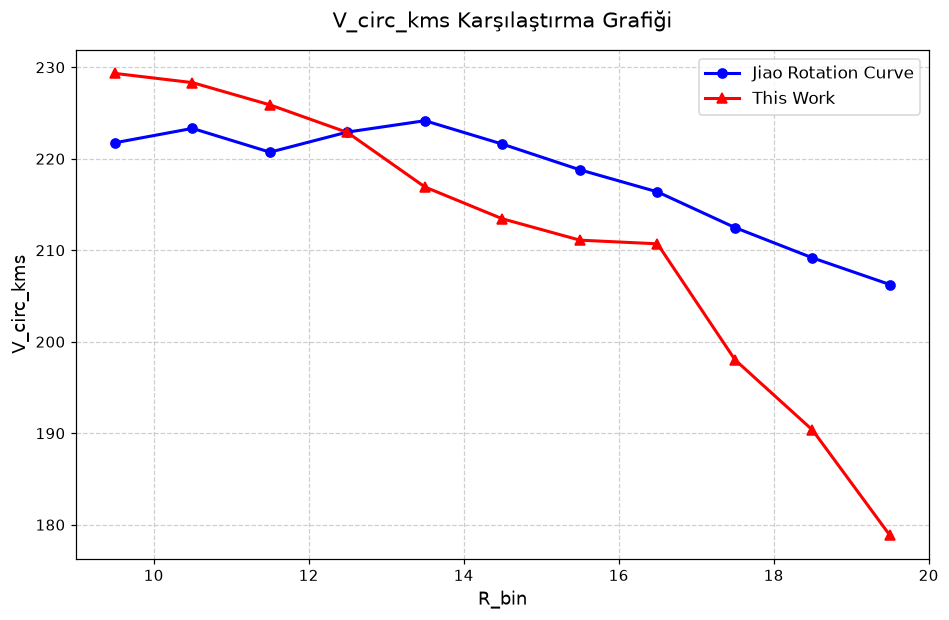

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    Jiao_dataFrame['R_bin'],
    Jiao_dataFrame['V_circ_kms'],
    label='Jiao Rotation Curve',
    color='blue',
    marker='o',
    linewidth=2,
)

plt.plot(
    jeans_terms_value_table['R_bin'],
    jeans_terms_value_table['V_circ_kms'],
    label='This Work',
    color='red',
    marker='^',
    linewidth=2,
)

plt.title('V_circ_kms Karşılaştırma Grafiği', fontsize=14, pad=15)
plt.xlabel('R_bin', fontsize=12)
plt.ylabel('V_circ_kms', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Arkaya kesikli kılavuz çizgileri ekler
plt.legend(fontsize=11)

plt.show()
